# 회귀 모델 입문

> 회귀(regression)는 숫자 값을 예측하는 머신러닝 문제입니다.

**머신러닝 문제**
| 구분 | 예측 결과 | 예시 |
|-----| --|--|
| 분류 (classification)| 범주, 클래스| 합격/불합격, 스팸/정상
|회귀(Regression)| 연속적인 숫자| 시험 점수, 매출액, 배송 시간

In [1]:
# 데이터 처리와 시각화를 위한 라이브러리
import pandas as pd
import matplotlib.pyplot as plt

# 머신러닝 도구
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 실습 데이터 만들기

학생의 공부시간, 출석률, 과제점수로 최종 시험 점수를 예측하기

In [2]:
student_df = pd.DataFrame({
    # 하루 평균 공부 시간
    "study_hours": [1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 11],
    # 출석률
    "attendance": [50, 55, 60, 58, 65, 70, 72, 75, 78, 80, 82, 85, 88, 90, 92, 93, 95, 96, 97, 98],
    # 과제 점수
    "assignment": [40, 45, 50, 52, 55, 60, 63, 68, 70, 75, 78, 82, 85, 88, 90, 92, 94, 95, 96, 98],
    # 최종 시험 점수, 모델이 예측해야 할 값
    "score": [45, 50, 53, 56, 60, 64, 67, 70, 73, 76, 79, 82, 85, 88, 90, 92, 94, 95, 96, 98]
})

## 데이터 살펴보기

모델을 만들기 전에 먼저 데이터의 모양을 확인해야 합니다.

In [3]:
student_df.describe()

,study_hours,attendance,assignment,score
count,20.000000,20.000000,20.000000,20.000000
mean,6.000000,78.950000,73.800000,75.650000
std,2.991215,15.226276,18.729656,16.828156
min,1.000000,50.000000,40.000000,45.000000
25%,3.750000,68.750000,58.750000,63.000000
50%,6.000000,81.000000,76.500000,77.500000
75%,8.250000,92.250000,90.500000,90.500000
max,11.000000,98.000000,98.000000,98.000000


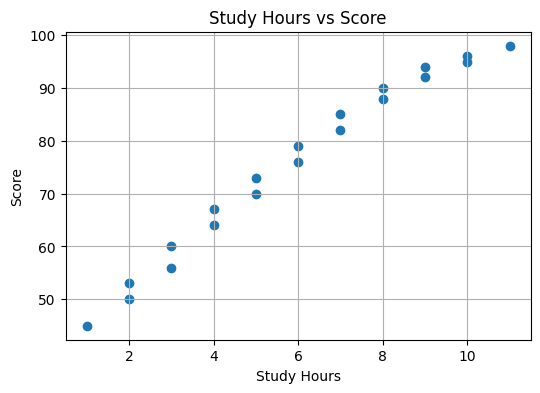

In [8]:
plt.figure(figsize=(6,4))
plt.scatter(student_df['study_hours'],student_df['score'])
plt.title('Study Hours vs Score')
plt.xlabel('Study Hours')
plt.ylabel('Score')
plt.grid(True)
plt.show()

## 입력(X)과 정답(Y) 분리하기

- X : `study_hours`
- Y : `score`

In [10]:
X = student_df[['study_hours']]
y = student_df['score']

print('X 모양:', X.shape)
print('y 모양:', y.shape)


X 모양: (20, 1)
y 모양: (20,)


## 훈련 데이터와 테스트 데이터 나누기

- 훈련 데이터 : 모델이 규칙을 배우는 데이터
- 테스트 데이터 : 모델이 처음 보는 데이터

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

print('훈련 데이터 개수:', len(X_train))
print('테스트 데이터 개수:', len(X_test))

훈련 데이터 개수: 14
테스트 데이터 개수: 6


## 선형 회귀 모델 학습하기

> 선형 회귀 모델 (LinearRegression)은 입력값과 예측값 사이의 관계를 직선으로 표현하는 모델

공부시간 하나로 점수를 예측한다면, 아래와 같은 식을 찾습니다.
```
예측 점수 = 기울기 X 공부시간 + 절편
```

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print('모델 학습 완료')
print('기울기', model.coef_[0])
print('절편', model.intercept_)

모델 학습 완료
기울기 5.393093313739896
절편 43.85819250551066


## 예측해보기

In [ ]:
pred = model.predict(X_test)

result_df = X_test.copy()
result_df['actual_score'] = y_test.values
result_df['predicted_score'] = pred.round(1)
result_df['error'] = (result_df['actual_score'] - result_df['predicted_score']).round(1)

# 실제 점수와 예측 점수를 나란히 비교
result_df

,study_hours,actual_score,predicted_score,error
0,1,45,49.3,-4.3
17,10,95,97.8,-2.8
15,9,92,92.4,-0.4
1,2,50,54.6,-4.6
8,5,73,70.8,2.2
5,4,64,65.4,-1.4


## 회귀 모델 평가 지표

**분류**에서는 정확도(Accuracy)를 자주 사용했으나, 회귀에서는 예측값이 숫자이므로 *얼마나 틀렸는지*를 봐야 합니다.

In [ ]:
from sklearn.metrics import mean_absolute_error

# MAE - 오차 절댓값의 평균 -> 평균적으로 몇 점 정도 틀리는가
mae = mean_absolute_error(y_test, pred)
# MSE - 오차 제곱의 평균 -> 큰 오차를 더 강하게 벌점
mse = mean_squared_error(y_test, pred)
# RMSE - MSE의 제곱근 -> 원래 단위로 해석 가능
rmse = mse ** 0.5
# R2 - 설명력 -> 1에 가까울수록 좋음
r2 = r2_score(y_test, pred)

print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R2: {r2:.3f}')

MAE: 2.61
MSE: 9.06
RMSE: 3.01
R2: 0.975


## 회귀선 시각화 하기

산점도 위에 모델이 학습한 직선을 그린다.<br>
직선이 데이터 흐름을 잘 따라가면 선형 회귀가 잘 작동하고 있다고 볼 수 있다.

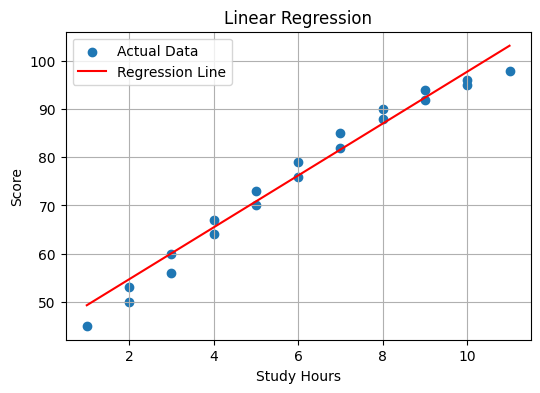

In [20]:
plt.figure(figsize=(6,4))
plt.scatter(
    student_df['study_hours'], student_df['score'], 
    label='Actual Data'
)

x_line = pd.DataFrame({
    'study_hours':[
        student_df['study_hours'].min(),
        student_df['study_hours'].max()
    ]
})
y_line = model.predict(x_line)

plt.plot(
    x_line['study_hours'], y_line, 
    color='red', 
    label='Regression Line'
)
plt.title('Linear Regression')
plt.xlabel('Study Hours')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

## 새 데이터 예측하기

공부 시간 7.5 시간 학생의 최종 점수를 예측해봅니다.

**주의사항**
- 학습할 때 , `DataFrame` 형태로 넣었다면, 예측할 때도 같은 컬럼명을 가진 `DataFrame` 을 넣어야 안전합니다.
- 입력 컬럼의 순서와 이름이 학습할 때와 같아야 합니다.

In [21]:
new_student = pd.DataFrame({
    'study_hours' : [7.5]
})
predicted_score = model.predict(new_student)[0]

print(f'예상 점수: {predicted_score:.1f}점')

예상 점수: 84.3점


# 다음주 예고, 여러 변수를 사용한 회귀 모델 만들기